# 🔍 Fraud Detection — Data Analysis & Rule Optimization

> **Dataset**: Kaggle Credit Card Fraud Detection (284,807 transactions, 2 ngày)  
> **Mục tiêu**: Phân tích phân phối dữ liệu và tối ưu ngưỡng cho `rules.jsonl`

---
## Nội dung
1. [Load & Tổng quan dữ liệu](#1)
2. [Phân phối Amount](#2)
3. [Phân tích P001 — Rapid Small Transactions](#3)
4. [Phân tích P002 — High Value New Location](#4)
5. [Phân tích P003 — Multiple Failed Then Success](#5)
6. [Blind Spot Analysis](#6)
7. [Đề xuất Rules mới & Cải thiện](#7)
8. [Xuất `rules.jsonl` đã tối ưu](#8)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
import json
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

# ── Style ──────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d2e',
    'axes.edgecolor':   '#2d3150',
    'axes.labelcolor':  '#c9d1d9',
    'axes.titlecolor':  '#e6edf3',
    'xtick.color':      '#8b949e',
    'ytick.color':      '#8b949e',
    'text.color':       '#c9d1d9',
    'grid.color':       '#2d3150',
    'grid.alpha':       0.6,
    'figure.titlesize': 16,
    'axes.titlesize':   13,
    'axes.labelsize':   11,
    'font.family':      'DejaVu Sans',
})

FRAUD_COLOR  = '#ff6b6b'
NORMAL_COLOR = '#4ecdc4'
ACCENT_COLOR = '#ffe66d'
INFO_COLOR   = '#a78bfa'

print('✅ Libraries loaded')

✅ Libraries loaded


---
## 1. Load & Tổng quan dữ liệu <a id='1'></a>

In [2]:
CSV_PATH   = Path('../ml/data/creditcard.csv')
RULES_PATH = Path('../rules.jsonl')

print('Loading dataset...')
df = pd.read_csv(CSV_PATH)
print(f'Shape: {df.shape}')

# Load existing rules
rules = []
with open(RULES_PATH) as f:
    for line in f:
        line = line.strip()
        if line:
            rules.append(json.loads(line))

print(f'Rules loaded: {len(rules)}')
pd.DataFrame(rules)

Loading dataset...


Shape: (284807, 31)
Rules loaded: 4


,ruleId,ruleName,enabled,thresholdAmount,windowSeconds,minOccurrences,severity,thresholdAmountHigh
0,P001,Rapid Small Transactions,True,20.0,60,3,HIGH,NaN
1,P002,High Value New Location,True,200.0,3600,1,CRITICAL,NaN
2,P003,Multiple Fraud Then Success,True,0.0,300,2,HIGH,NaN
3,P004,Mid-Range Velocity,True,50.0,600,2,MEDIUM,500.0


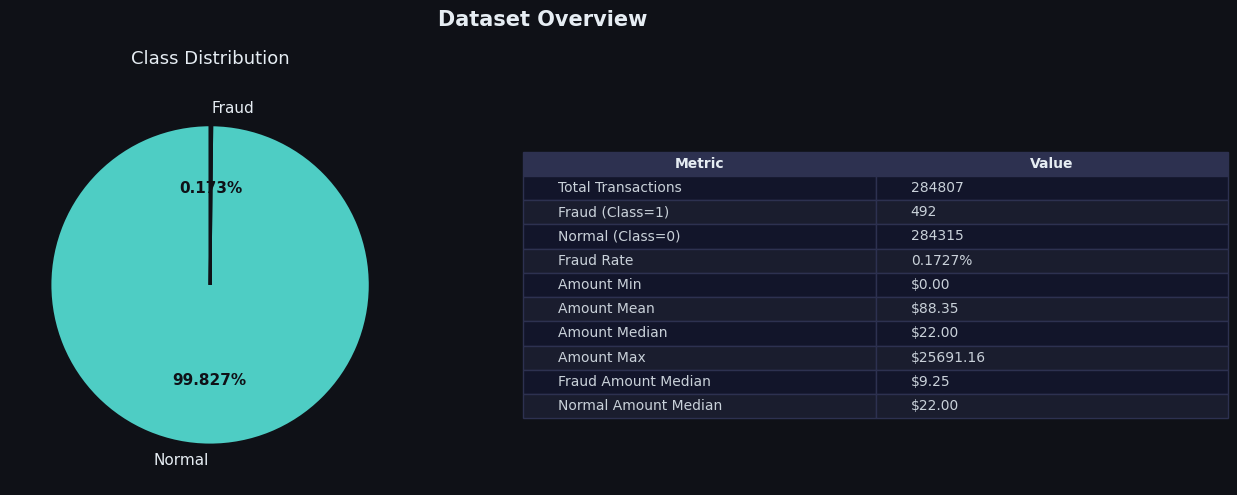


Dataset statistics printed above.


In [3]:
fraud  = df[df['Class'] == 1]
normal = df[df['Class'] == 0]

stats = {
    'Total Transactions':     len(df),
    'Fraud (Class=1)':        len(fraud),
    'Normal (Class=0)':       len(normal),
    'Fraud Rate':             f'{len(fraud)/len(df)*100:.4f}%',
    'Amount Min':             f'${df["Amount"].min():.2f}',
    'Amount Mean':            f'${df["Amount"].mean():.2f}',
    'Amount Median':          f'${df["Amount"].median():.2f}',
    'Amount Max':             f'${df["Amount"].max():.2f}',
    'Fraud Amount Median':    f'${fraud["Amount"].median():.2f}',
    'Normal Amount Median':   f'${normal["Amount"].median():.2f}',
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Dataset Overview', fontsize=15, fontweight='bold', color='#e6edf3')

# Pie chart
ax = axes[0]
sizes  = [len(normal), len(fraud)]
colors = [NORMAL_COLOR, FRAUD_COLOR]
wedges, texts, autotexts = ax.pie(
    sizes, labels=['Normal', 'Fraud'], colors=colors,
    autopct='%1.3f%%', startangle=90,
    textprops={'color': '#e6edf3', 'fontsize': 11},
    wedgeprops={'edgecolor': '#0f1117', 'linewidth': 2}
)
for at in autotexts:
    at.set_color('#0f1117')
    at.set_fontweight('bold')
ax.set_title('Class Distribution', pad=15)

# Stats table
ax2 = axes[1]
ax2.axis('off')
table_data = [[k, v] for k, v in stats.items()]
table = ax2.table(
    cellText=table_data,
    colLabels=['Metric', 'Value'],
    loc='center', cellLoc='left'
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.4)
for (r, c), cell in table.get_celld().items():
    cell.set_facecolor('#1a1d2e' if r % 2 == 0 else '#12152a')
    cell.set_edgecolor('#2d3150')
    cell.set_text_props(color='#c9d1d9')
    if r == 0:
        cell.set_facecolor('#2d3150')
        cell.set_text_props(color='#e6edf3', fontweight='bold')

plt.tight_layout()
plt.show()
print('\nDataset statistics printed above.')

---
## 2. Phân phối Amount <a id='2'></a>

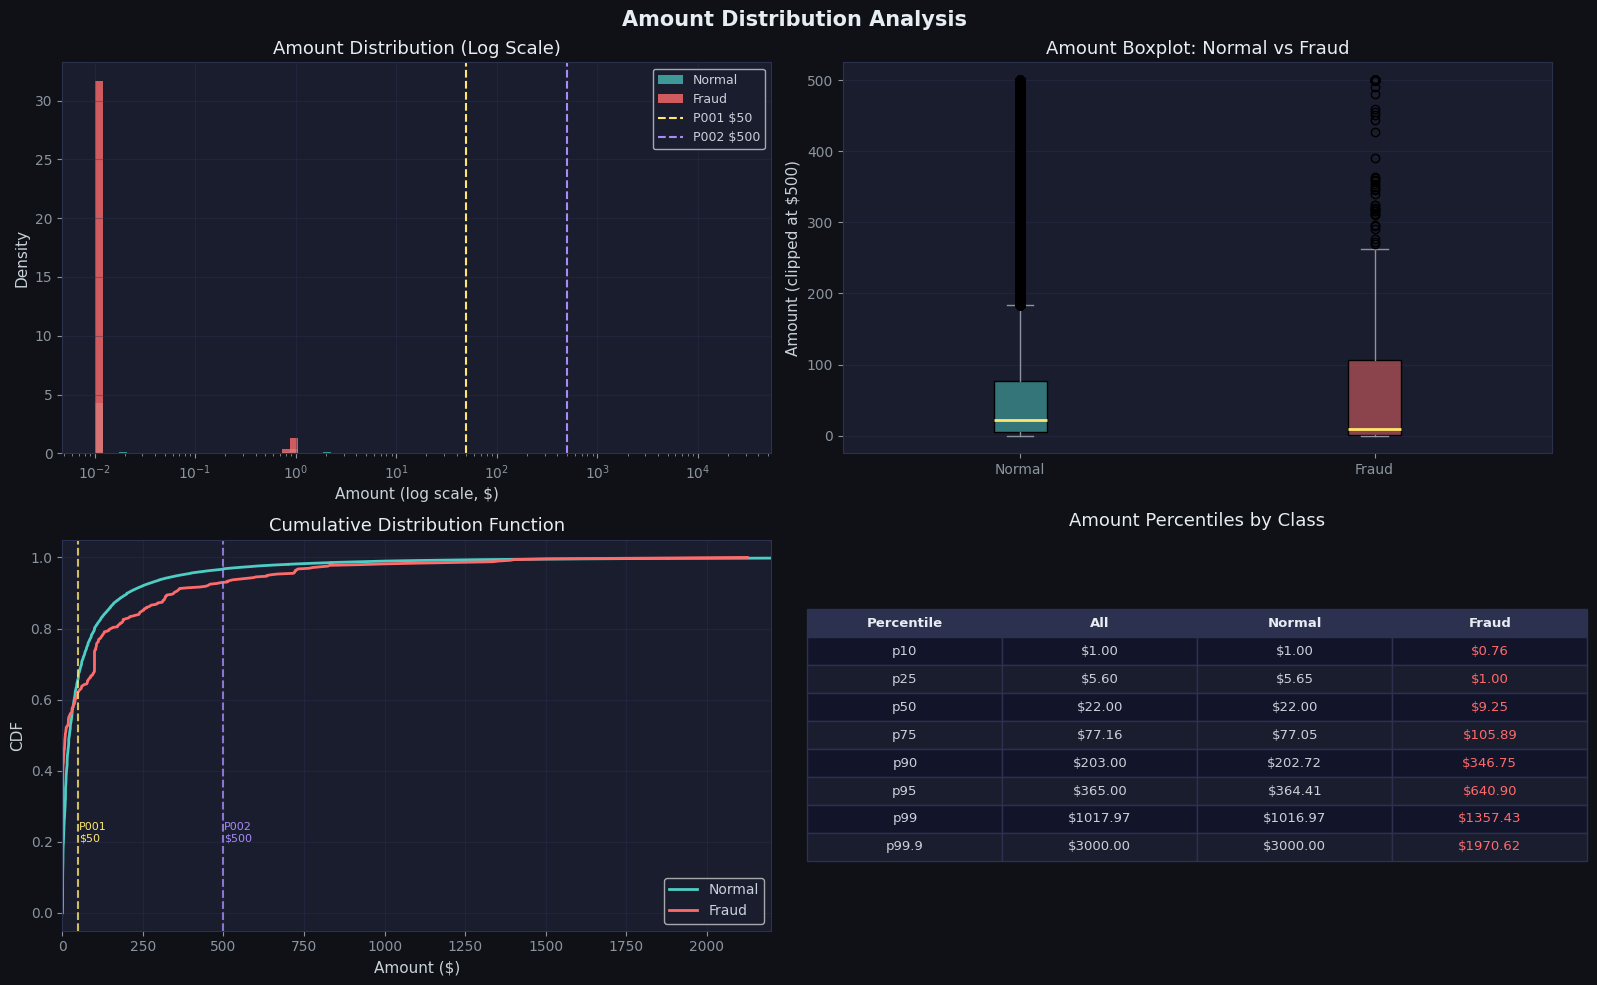

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Amount Distribution Analysis', fontsize=15, fontweight='bold', color='#e6edf3')

# 1. Overall log-scale histogram
ax = axes[0, 0]
bins = np.logspace(np.log10(0.01), np.log10(df['Amount'].max() + 1), 80)
ax.hist(normal['Amount'].clip(lower=0.01), bins=bins, alpha=0.7, color=NORMAL_COLOR, label='Normal', density=True)
ax.hist(fraud['Amount'].clip(lower=0.01),  bins=bins, alpha=0.8, color=FRAUD_COLOR,  label='Fraud',  density=True)
ax.set_xscale('log')
ax.set_xlabel('Amount (log scale, $)')
ax.set_ylabel('Density')
ax.set_title('Amount Distribution (Log Scale)')
ax.legend()
ax.grid(True, alpha=0.4)
# Rule threshold lines
ax.axvline(50,  color=ACCENT_COLOR, lw=1.5, ls='--', label='P001 $50')
ax.axvline(500, color=INFO_COLOR,   lw=1.5, ls='--', label='P002 $500')
ax.legend(fontsize=9)

# 2. Boxplot comparison
ax = axes[0, 1]
bp_data = [normal['Amount'].clip(upper=500), fraud['Amount'].clip(upper=500)]
bp = ax.boxplot(bp_data, labels=['Normal', 'Fraud'], patch_artist=True,
                medianprops={'color': '#ffe66d', 'linewidth': 2})
bp['boxes'][0].set_facecolor(NORMAL_COLOR + '80')
bp['boxes'][1].set_facecolor(FRAUD_COLOR + '80')
for element in ['whiskers', 'caps', 'fliers']:
    for item in bp[element]:
        item.set_color('#8b949e')
ax.set_ylabel('Amount (clipped at $500)')
ax.set_title('Amount Boxplot: Normal vs Fraud')
ax.grid(True, alpha=0.4, axis='y')

# 3. CDF comparison
ax = axes[1, 0]
for subset, color, label in [(normal, NORMAL_COLOR, 'Normal'), (fraud, FRAUD_COLOR, 'Fraud')]:
    sorted_amt = np.sort(subset['Amount'])
    cdf = np.arange(1, len(sorted_amt) + 1) / len(sorted_amt)
    ax.plot(sorted_amt, cdf, color=color, lw=2, label=label)
ax.axvline(50,  color=ACCENT_COLOR, lw=1.5, ls='--', alpha=0.8)
ax.axvline(500, color=INFO_COLOR,   lw=1.5, ls='--', alpha=0.8)
ax.text(52,  0.2, 'P001\n$50',  color=ACCENT_COLOR, fontsize=8)
ax.text(502, 0.2, 'P002\n$500', color=INFO_COLOR,   fontsize=8)
ax.set_xlabel('Amount ($)')
ax.set_ylabel('CDF')
ax.set_title('Cumulative Distribution Function')
ax.set_xlim(0, 2200)
ax.legend()
ax.grid(True, alpha=0.4)

# 4. Percentile table
ax = axes[1, 1]
ax.axis('off')
percentiles = [10, 25, 50, 75, 90, 95, 99, 99.9]
rows = []
for p in percentiles:
    rows.append([
        f'p{p}',
        f'${df["Amount"].quantile(p/100):.2f}',
        f'${normal["Amount"].quantile(p/100):.2f}',
        f'${fraud["Amount"].quantile(p/100):.2f}',
    ])
table = ax.table(
    cellText=rows,
    colLabels=['Percentile', 'All', 'Normal', 'Fraud'],
    loc='center', cellLoc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(9.5)
table.scale(1.1, 1.5)
for (r, c), cell in table.get_celld().items():
    cell.set_facecolor('#1a1d2e' if r % 2 == 0 else '#12152a')
    cell.set_edgecolor('#2d3150')
    cell.set_text_props(color='#c9d1d9')
    if r == 0:
        cell.set_facecolor('#2d3150')
        cell.set_text_props(color='#e6edf3', fontweight='bold')
    if c == 3 and r > 0:  # Fraud column highlight
        cell.set_text_props(color=FRAUD_COLOR)
ax.set_title('Amount Percentiles by Class', pad=10)

plt.tight_layout()
plt.show()

---
## 3. Phân tích P001 — Rapid Small Transactions <a id='3'></a>


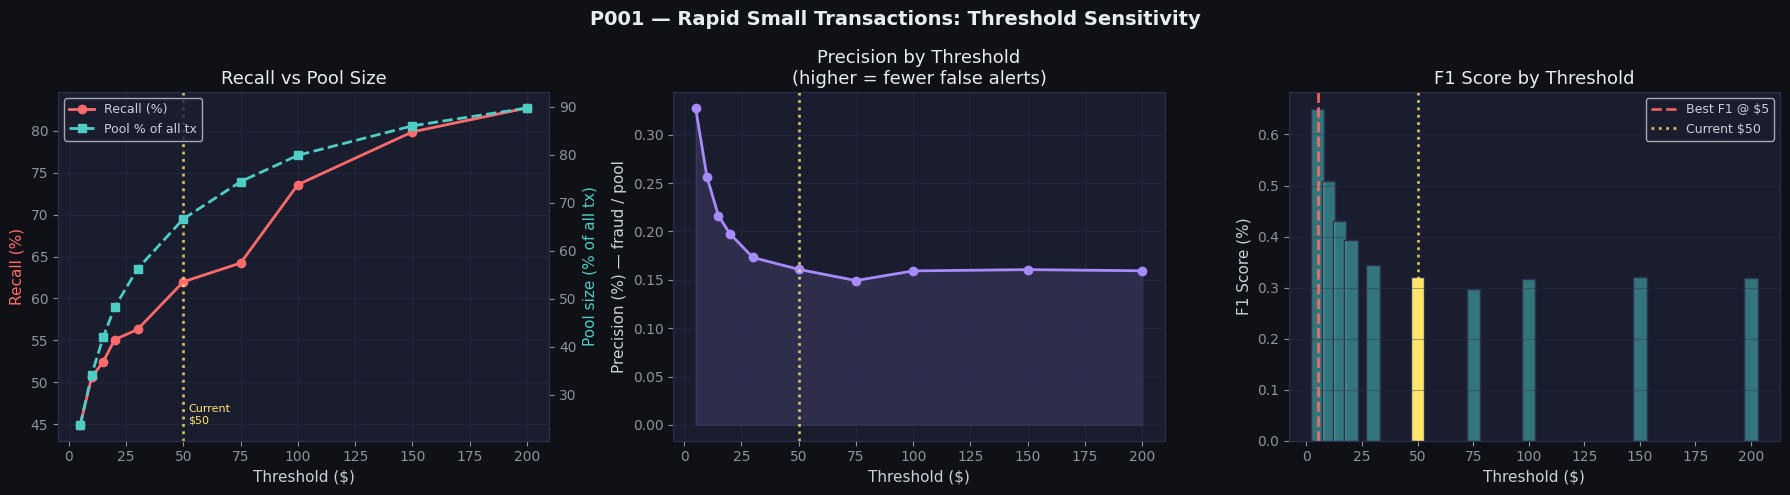


📊 P001 Metrics Table:


,threshold,pool_size,pool_pct,fraud_caught,precision,recall,f1
0,5,67463,23.7%,221,0.328%,44.9%,0.6504%
1,10,97314,34.2%,249,0.256%,50.6%,0.5092%
2,15,119370,41.9%,258,0.216%,52.4%,0.4305%
3,20,137128,48.1%,271,0.198%,55.1%,0.3938%
4,30,160068,56.2%,277,0.173%,56.3%,0.3450%
5,50,189704,66.6%,305,0.161%,62.0%,0.3207%
6,75,211780,74.4%,316,0.149%,64.2%,0.2977%
7,100,227422,79.9%,362,0.159%,73.6%,0.3177%
8,150,244893,86.0%,393,0.160%,79.9%,0.3203%
9,200,255492,89.7%,407,0.159%,82.7%,0.3180%



✅ Recommended: threshold=$5 (best F1=0.6504%)
   Current $50: F1=0.3207%


In [ ]:
thresholds_p001 = [5, 10, 15, 20, 30, 50, 75, 100, 150, 200]

p001_metrics = []
for t in thresholds_p001:
    pool       = df[df['Amount'] < t]
    pool_fraud = pool[pool['Class'] == 1]
    tp         = len(pool_fraud)
    fp         = len(pool) - tp
    fn         = len(fraud) - tp
    precision  = tp / len(pool) * 100 if len(pool) > 0 else 0
    recall     = tp / len(fraud) * 100
    f1         = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    p001_metrics.append({
        'threshold': t,
        'pool_size': len(pool),
        'pool_pct':  len(pool)/len(df)*100,
        'fraud_caught': tp,
        'precision': precision,
        'recall':    recall,
        'f1':        f1,
    })

df_p001 = pd.DataFrame(p001_metrics)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('P001 — Rapid Small Transactions: Threshold Sensitivity', fontsize=14, fontweight='bold', color='#e6edf3')

# Recall & Pool size
ax = axes[0]
ax2r = ax.twinx()
ln1 = ax.plot(df_p001['threshold'], df_p001['recall'], 'o-', color=FRAUD_COLOR,  lw=2, ms=6, label='Recall (%)')
ln2 = ax2r.plot(df_p001['threshold'], df_p001['pool_pct'], 's--', color=NORMAL_COLOR, lw=2, ms=6, label='Pool % of all tx')
ax.axvline(50, color=ACCENT_COLOR, lw=2, ls=':', alpha=0.8)
ax.text(52, ax.get_ylim()[0] + 2, 'Current\n$50', color=ACCENT_COLOR, fontsize=8)
ax.set_xlabel('Threshold ($)')
ax.set_ylabel('Recall (%)', color=FRAUD_COLOR)
ax2r.set_ylabel('Pool size (% of all tx)', color=NORMAL_COLOR)
ax.set_title('Recall vs Pool Size')
ax.grid(True, alpha=0.4)
lines = ln1 + ln2
ax.legend(lines, [l.get_label() for l in lines], fontsize=9, loc='upper left')

# Precision
ax = axes[1]
ax.plot(df_p001['threshold'], df_p001['precision'], 'o-', color=INFO_COLOR, lw=2, ms=6)
ax.axvline(50, color=ACCENT_COLOR, lw=2, ls=':', alpha=0.8)
ax.fill_between(df_p001['threshold'], df_p001['precision'], alpha=0.15, color=INFO_COLOR)
ax.set_xlabel('Threshold ($)')
ax.set_ylabel('Precision (%) — fraud / pool')
ax.set_title('Precision by Threshold\n(higher = fewer false alerts)')
ax.grid(True, alpha=0.4)

# F1 score
ax = axes[2]
bars = ax.bar(df_p001['threshold'], df_p001['f1'],
              color=[ACCENT_COLOR if t == 50 else '#4ecdc480' for t in df_p001['threshold']],
              edgecolor='#2d3150', width=6)
best_idx = df_p001['f1'].idxmax()
best_t   = df_p001.loc[best_idx, 'threshold']
ax.axvline(best_t, color=FRAUD_COLOR, lw=2, ls='--', alpha=0.9, label=f'Best F1 @ ${best_t}')
ax.axvline(50,     color=ACCENT_COLOR, lw=2, ls=':', alpha=0.8, label='Current $50')
ax.set_xlabel('Threshold ($)')
ax.set_ylabel('F1 Score (%)')
ax.set_title('F1 Score by Threshold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.4, axis='y')

plt.tight_layout()
plt.show()

print('\n📊 P001 Metrics Table:')
display(df_p001.style
    .format({'pool_pct': '{:.1f}%', 'precision': '{:.3f}%', 'recall': '{:.1f}%', 'f1': '{:.4f}%'})
    .highlight_max(subset=['recall', 'f1'], color='#2d5016')
    .highlight_min(subset=['precision'], color='#5c1a1a')
    .set_properties(**{'background-color': '#1a1d2e', 'color': '#c9d1d9', 'border': '1px solid #2d3150'})
)

print(f"\n✅ Recommended: threshold=${best_t} (best F1={df_p001.loc[best_idx,'f1']:.4f}%)")
print(f"   Current $50: F1={df_p001[df_p001['threshold']==50]['f1'].values[0]:.4f}%")

---
## 4. Phân tích P002 — High Value New Location <a id='4'></a>

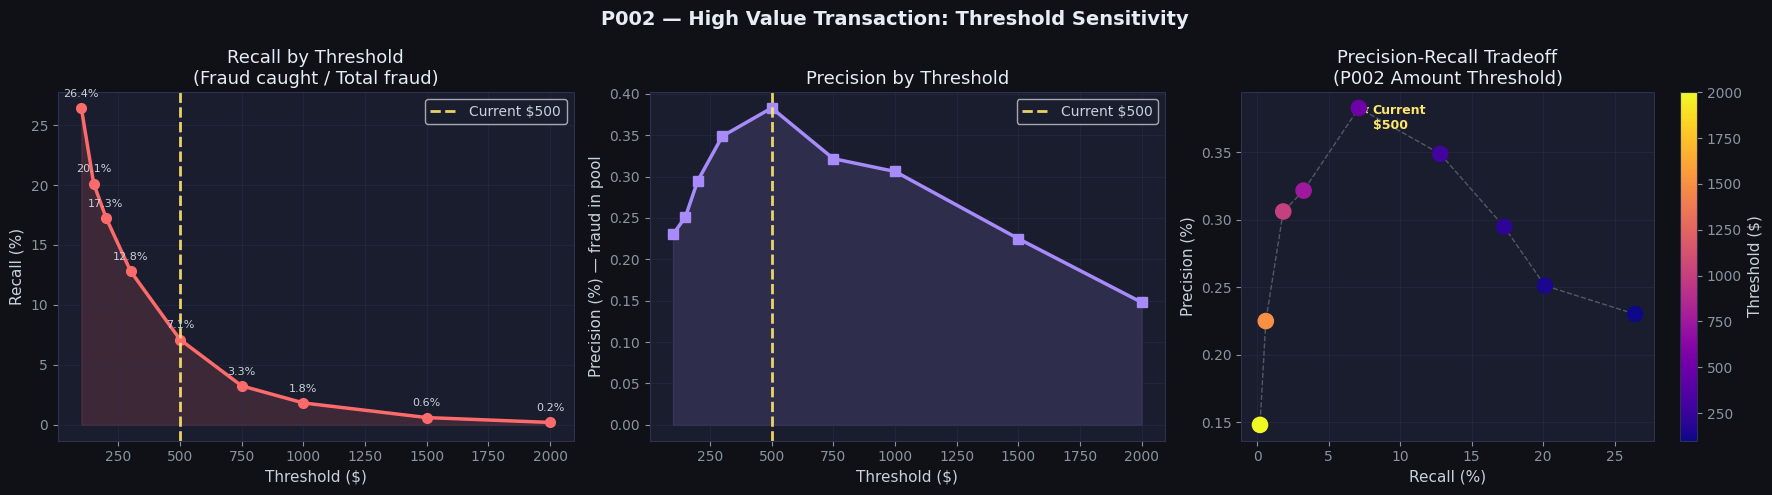


📊 P002 Metrics Table:


,threshold,pool_size,pool_pct,fraud_caught,precision,recall,f1
0,100,56508,19.84%,130,0.230%,26.4%,0.4561%
1,150,39417,13.84%,99,0.251%,20.1%,0.4961%
2,200,28837,10.13%,85,0.295%,17.3%,0.5796%
3,300,18061,6.34%,63,0.349%,12.8%,0.6791%
4,500,9142,3.21%,35,0.383%,7.1%,0.7266%
5,750,4975,1.75%,16,0.322%,3.3%,0.5853%
6,1000,2940,1.03%,9,0.306%,1.8%,0.5245%
7,1500,1334,0.47%,3,0.225%,0.6%,0.3286%
8,2000,676,0.24%,1,0.148%,0.2%,0.1712%



⚠️  Current $500: Recall=7.1%, Precision=0.383%
✅  Best F1 @ $500: Recall=7.1%, Precision=0.383%


In [6]:
thresholds_p002 = [100, 150, 200, 300, 500, 750, 1000, 1500, 2000]

p002_metrics = []
for t in thresholds_p002:
    pool       = df[df['Amount'] > t]
    pool_fraud = pool[pool['Class'] == 1]
    tp         = len(pool_fraud)
    precision  = tp / len(pool) * 100 if len(pool) > 0 else 0
    recall     = tp / len(fraud) * 100
    f1         = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    p002_metrics.append({
        'threshold': t,
        'pool_size': len(pool),
        'pool_pct':  len(pool)/len(df)*100,
        'fraud_caught': tp,
        'precision': precision,
        'recall':    recall,
        'f1':        f1,
    })

df_p002 = pd.DataFrame(p002_metrics)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('P002 — High Value Transaction: Threshold Sensitivity', fontsize=14, fontweight='bold', color='#e6edf3')

# Recall drop-off
ax = axes[0]
ax.plot(df_p002['threshold'], df_p002['recall'], 'o-', color=FRAUD_COLOR, lw=2.5, ms=7)
ax.fill_between(df_p002['threshold'], df_p002['recall'], alpha=0.15, color=FRAUD_COLOR)
ax.axvline(500, color=ACCENT_COLOR, lw=2, ls='--', alpha=0.9, label='Current $500')
ax.set_xlabel('Threshold ($)')
ax.set_ylabel('Recall (%)')
ax.set_title('Recall by Threshold\n(Fraud caught / Total fraud)')
ax.legend()
ax.grid(True, alpha=0.4)
# Annotate each point
for _, row in df_p002.iterrows():
    ax.annotate(f'{row["recall"]:.1f}%', (row['threshold'], row['recall']),
                textcoords='offset points', xytext=(0, 8), fontsize=8, color='#c9d1d9', ha='center')

# Precision improvement
ax = axes[1]
ax.plot(df_p002['threshold'], df_p002['precision'], 's-', color=INFO_COLOR, lw=2.5, ms=7)
ax.fill_between(df_p002['threshold'], df_p002['precision'], alpha=0.15, color=INFO_COLOR)
ax.axvline(500, color=ACCENT_COLOR, lw=2, ls='--', alpha=0.9, label='Current $500')
ax.set_xlabel('Threshold ($)')
ax.set_ylabel('Precision (%) — fraud in pool')
ax.set_title('Precision by Threshold')
ax.legend()
ax.grid(True, alpha=0.4)

# Precision-Recall tradeoff curve
ax = axes[2]
sc = ax.scatter(df_p002['recall'], df_p002['precision'],
                c=df_p002['threshold'], cmap='plasma', s=120, zorder=5)
ax.plot(df_p002['recall'], df_p002['precision'], '--', color='#8b949e', lw=1, alpha=0.5)
plt.colorbar(sc, ax=ax, label='Threshold ($)')
# Annotate current
curr = df_p002[df_p002['threshold'] == 500].iloc[0]
ax.annotate('Current\n$500', (curr['recall'], curr['precision']),
            textcoords='offset points', xytext=(10, -15),
            color=ACCENT_COLOR, fontsize=9, fontweight='bold',
            arrowprops={'arrowstyle': '->', 'color': ACCENT_COLOR})
ax.set_xlabel('Recall (%)')
ax.set_ylabel('Precision (%)')
ax.set_title('Precision-Recall Tradeoff\n(P002 Amount Threshold)')
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

print('\n📊 P002 Metrics Table:')
display(df_p002.style
    .format({'pool_pct': '{:.2f}%', 'precision': '{:.3f}%', 'recall': '{:.1f}%', 'f1': '{:.4f}%'})
    .set_properties(**{'background-color': '#1a1d2e', 'color': '#c9d1d9', 'border': '1px solid #2d3150'})
)
best_idx = df_p002['f1'].idxmax()
print(f"\n⚠️  Current $500: Recall={curr['recall']:.1f}%, Precision={curr['precision']:.3f}%")
print(f"✅  Best F1 @ ${df_p002.loc[best_idx,'threshold']}: "
      f"Recall={df_p002.loc[best_idx,'recall']:.1f}%, Precision={df_p002.loc[best_idx,'precision']:.3f}%")

---
## 5. Phân tích P003 — Multiple Failed Then Success <a id='5'></a>

**Note**: Dataset không có `status` field. P003 phụ thuộc vào Kafka event stream.  
Chúng ta phân tích **time-based patterns** của fraud để validate window 300s.

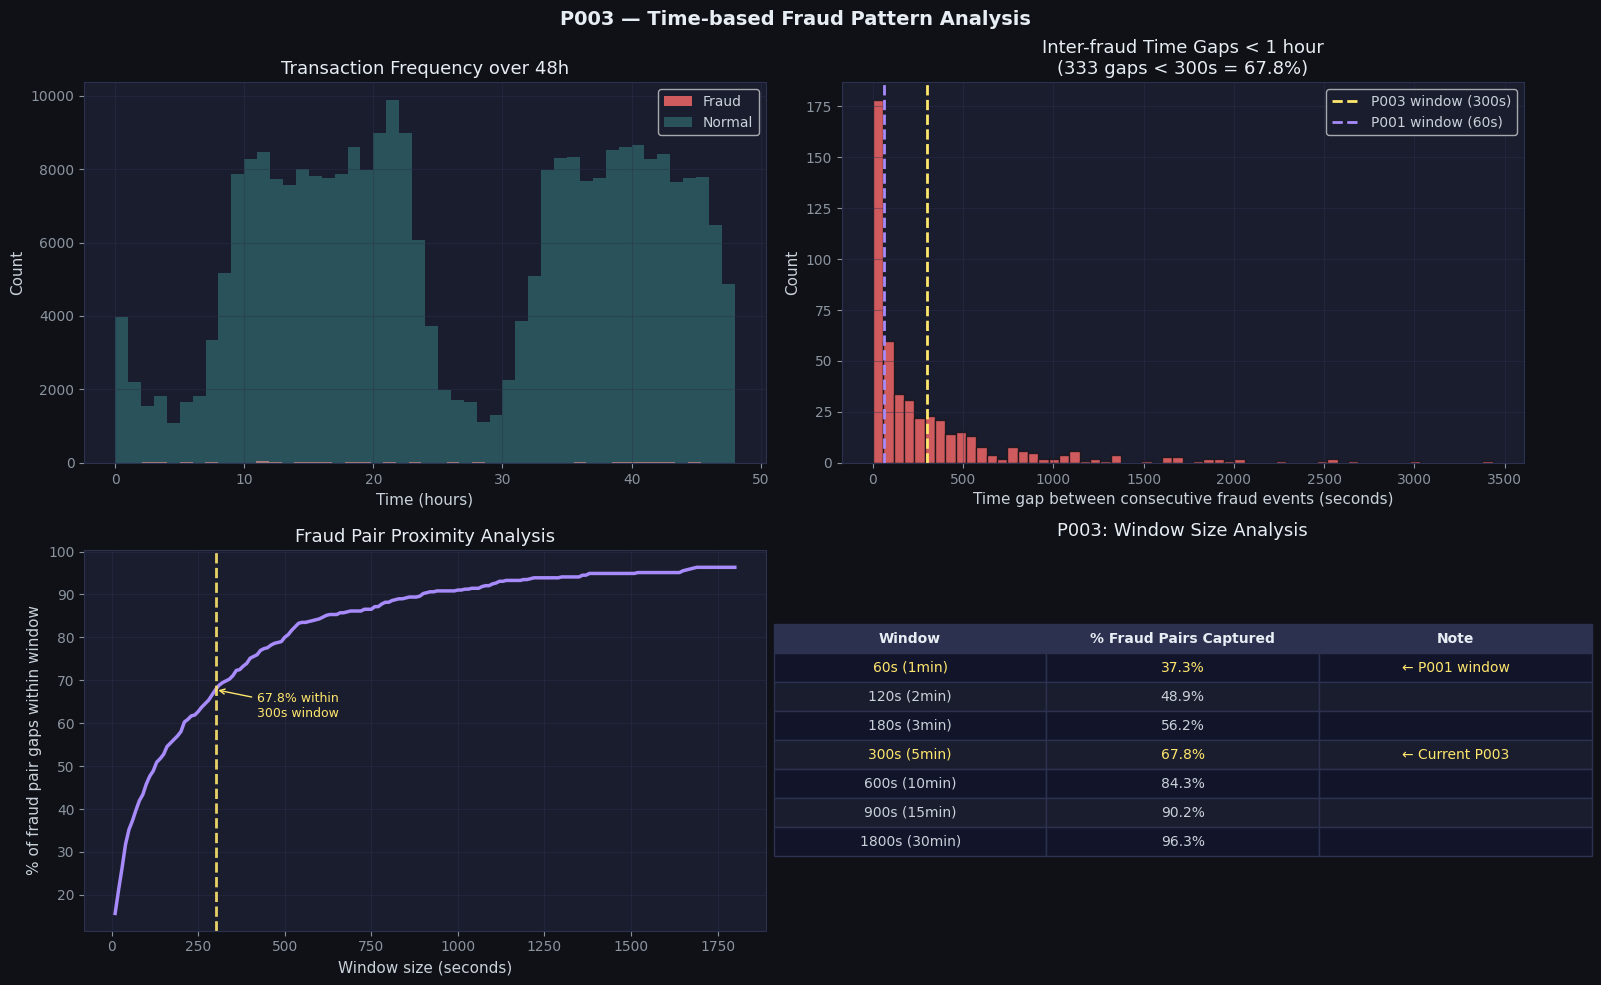


📊 Inter-fraud gap stats:
  Median gap: 126s (2.1 min)
  Mean gap  : 346s (5.8 min)
  Gaps < 300s: 333 (67.8%)

✅ P003 windowSeconds=300 hợp lý — bắt được 67.8% các cặp fraud gần nhau


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('P003 — Time-based Fraud Pattern Analysis', fontsize=14, fontweight='bold', color='#e6edf3')

# 1. Fraud transactions over time (48h)
ax = axes[0, 0]
time_bins = np.arange(0, df['Time'].max() + 3600, 3600)  # 1-hour bins
ax.hist(fraud['Time'] / 3600, bins=48, color=FRAUD_COLOR, alpha=0.8, label='Fraud')
ax.hist(normal['Time'] / 3600, bins=48, color=NORMAL_COLOR, alpha=0.3, label='Normal', density=False)
ax.set_xlabel('Time (hours)')
ax.set_ylabel('Count')
ax.set_title('Transaction Frequency over 48h')
ax.legend()
ax.grid(True, alpha=0.4)

# 2. Inter-fraud time gaps
ax = axes[0, 1]
fraud_sorted = fraud.sort_values('Time')
time_gaps    = fraud_sorted['Time'].diff().dropna()
gaps_under_1h = time_gaps[time_gaps < 3600]
ax.hist(gaps_under_1h, bins=60, color=FRAUD_COLOR, alpha=0.8, edgecolor='#0f1117')
ax.axvline(300, color=ACCENT_COLOR, lw=2, ls='--', label='P003 window (300s)')
ax.axvline(60,  color=INFO_COLOR,   lw=2, ls='--', label='P001 window (60s)')
gap_within_300 = (time_gaps < 300).sum()
ax.set_xlabel('Time gap between consecutive fraud events (seconds)')
ax.set_ylabel('Count')
ax.set_title(f'Inter-fraud Time Gaps < 1 hour\n({gap_within_300} gaps < 300s = {gap_within_300/len(time_gaps)*100:.1f}%)')
ax.legend()
ax.grid(True, alpha=0.4)

# 3. Cumulative % of fraud pairs within window X
ax = axes[1, 0]
windows = np.arange(10, 1810, 10)  # 10s to 30min
pct_within = [(time_gaps < w).sum() / len(time_gaps) * 100 for w in windows]
ax.plot(windows, pct_within, color=INFO_COLOR, lw=2.5)
ax.axvline(300, color=ACCENT_COLOR, lw=2, ls='--', alpha=0.9)
pct_at_300 = (time_gaps < 300).sum() / len(time_gaps) * 100
ax.annotate(f'{pct_at_300:.1f}% within\n300s window',
            (300, pct_at_300),
            textcoords='offset points', xytext=(30, -20),
            color=ACCENT_COLOR, fontsize=9,
            arrowprops={'arrowstyle': '->', 'color': ACCENT_COLOR})
ax.set_xlabel('Window size (seconds)')
ax.set_ylabel('% of fraud pair gaps within window')
ax.set_title('Fraud Pair Proximity Analysis')
ax.grid(True, alpha=0.4)

# 4. Window recommendation table
ax = axes[1, 1]
ax.axis('off')
window_options = [60, 120, 180, 300, 600, 900, 1800]
w_rows = []
for w in window_options:
    pct = (time_gaps < w).sum() / len(time_gaps) * 100
    note = '← Current P003' if w == 300 else ('← P001 window' if w == 60 else '')
    w_rows.append([f'{w}s ({w//60}min)', f'{pct:.1f}%', note])
table = ax.table(
    cellText=w_rows,
    colLabels=['Window', '% Fraud Pairs Captured', 'Note'],
    loc='center', cellLoc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.6)
for (r, c), cell in table.get_celld().items():
    cell.set_facecolor('#1a1d2e' if r % 2 == 0 else '#12152a')
    cell.set_edgecolor('#2d3150')
    cell.set_text_props(color='#c9d1d9')
    if r == 0:
        cell.set_facecolor('#2d3150')
        cell.set_text_props(color='#e6edf3', fontweight='bold')
    if r > 0 and w_rows[r-1][2]:
        cell.set_text_props(color=ACCENT_COLOR)
ax.set_title('P003: Window Size Analysis', pad=10)

plt.tight_layout()
plt.show()

print(f'\n📊 Inter-fraud gap stats:')
print(f'  Median gap: {time_gaps.median():.0f}s ({time_gaps.median()/60:.1f} min)')
print(f'  Mean gap  : {time_gaps.mean():.0f}s ({time_gaps.mean()/60:.1f} min)')
print(f'  Gaps < 300s: {gap_within_300} ({gap_within_300/len(time_gaps)*100:.1f}%)')
print(f'\n✅ P003 windowSeconds=300 hợp lý — bắt được {pct_at_300:.1f}% các cặp fraud gần nhau')

---
## 6. Blind Spot Analysis <a id='6'></a>

Phân tích vùng fraud **không được bắt** bởi rules hiện tại.

P001 zone  (< $50)    : 305 fraud (62.0%)
P002 zone  (> $500)   :  35 fraud (7.1%)
Blind spot ($50-$500) : 152 fraud (30.9%)


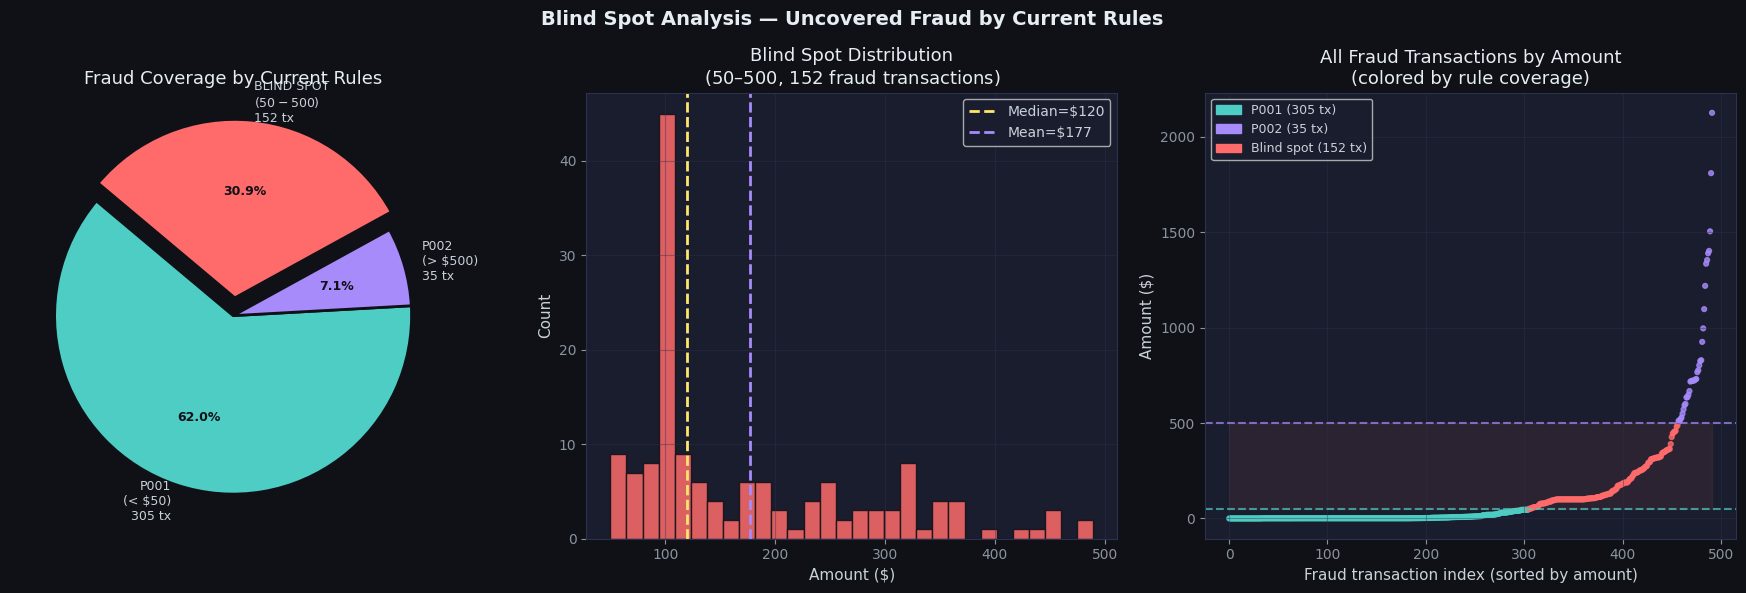


💡 Blind spot characteristics:
  Amount: $50.00 – $489.71
  Median: $120.14, Mean: $177.03
  → Need a P004 rule targeting this range


In [8]:
# Zones
zone_p001 = fraud[fraud['Amount'] < 50]            # P001 catches
zone_p002 = fraud[fraud['Amount'] > 500]           # P002 catches
zone_blind = fraud[(fraud['Amount'] >= 50) & (fraud['Amount'] <= 500)]  # Neither

print(f'P001 zone  (< $50)    : {len(zone_p001):3d} fraud ({len(zone_p001)/len(fraud)*100:.1f}%)')
print(f'P002 zone  (> $500)   : {len(zone_p002):3d} fraud ({len(zone_p002)/len(fraud)*100:.1f}%)')
print(f'Blind spot ($50-$500) : {len(zone_blind):3d} fraud ({len(zone_blind)/len(fraud)*100:.1f}%)')

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Blind Spot Analysis — Uncovered Fraud by Current Rules', fontsize=14, fontweight='bold', color='#e6edf3')

# 1. Coverage pie
ax = axes[0]
sizes  = [len(zone_p001), len(zone_p002), len(zone_blind)]
labels = [f'P001\n(< $50)\n{len(zone_p001)} tx', f'P002\n(> $500)\n{len(zone_p002)} tx', f'BLIND SPOT\n($50-$500)\n{len(zone_blind)} tx']
colors = [NORMAL_COLOR, INFO_COLOR, FRAUD_COLOR]
explode = (0, 0, 0.1)
wedges, texts, autotexts = ax.pie(
    sizes, labels=labels, colors=colors, explode=explode,
    autopct='%1.1f%%', startangle=140,
    textprops={'color': '#c9d1d9', 'fontsize': 9},
    wedgeprops={'edgecolor': '#0f1117', 'linewidth': 2}
)
for at in autotexts:
    at.set_color('#0f1117')
    at.set_fontweight('bold')
ax.set_title('Fraud Coverage by Current Rules')

# 2. Blind spot amount distribution
ax = axes[1]
ax.hist(zone_blind['Amount'], bins=30, color=FRAUD_COLOR, alpha=0.85, edgecolor='#0f1117')
ax.axvline(zone_blind['Amount'].median(), color=ACCENT_COLOR, lw=2, ls='--',
           label=f'Median=${zone_blind["Amount"].median():.0f}')
ax.axvline(zone_blind['Amount'].mean(), color=INFO_COLOR, lw=2, ls='--',
           label=f'Mean=${zone_blind["Amount"].mean():.0f}')
ax.set_xlabel('Amount ($)')
ax.set_ylabel('Count')
ax.set_title(f'Blind Spot Distribution\n($50–$500, {len(zone_blind)} fraud transactions)')
ax.legend()
ax.grid(True, alpha=0.4)

# 3. Proposal: P004 coverage
ax = axes[2]
p004_thresh_lo = 50
p004_thresh_hi = 500

# Show all fraud with color zones
amounts = np.sort(fraud['Amount'].values)
colors_per = [
    NORMAL_COLOR if a < 50 else
    INFO_COLOR   if a > 500 else
    FRAUD_COLOR
    for a in amounts
]
ax.scatter(range(len(amounts)), amounts, c=colors_per, s=12, alpha=0.8)
ax.axhline(50,  color=NORMAL_COLOR, lw=1.5, ls='--', alpha=0.7, label='P001 $50')
ax.axhline(500, color=INFO_COLOR,   lw=1.5, ls='--', alpha=0.7, label='P002 $500')
ax.fill_between(range(len(amounts)), 50, 500, alpha=0.08, color=FRAUD_COLOR, label='Blind spot zone')
p001_patch  = mpatches.Patch(color=NORMAL_COLOR, label=f'P001 ({len(zone_p001)} tx)')
p002_patch  = mpatches.Patch(color=INFO_COLOR,   label=f'P002 ({len(zone_p002)} tx)')
blind_patch = mpatches.Patch(color=FRAUD_COLOR,  label=f'Blind spot ({len(zone_blind)} tx)')
ax.legend(handles=[p001_patch, p002_patch, blind_patch], fontsize=9)
ax.set_xlabel('Fraud transaction index (sorted by amount)')
ax.set_ylabel('Amount ($)')
ax.set_title('All Fraud Transactions by Amount\n(colored by rule coverage)')
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

print(f'\n💡 Blind spot characteristics:')
print(f'  Amount: ${zone_blind["Amount"].min():.2f} – ${zone_blind["Amount"].max():.2f}')
print(f'  Median: ${zone_blind["Amount"].median():.2f}, Mean: ${zone_blind["Amount"].mean():.2f}')
print(f'  → Need a P004 rule targeting this range')

---
## 7. Đề xuất Rules mới & Cải thiện <a id='7'></a>

Tổng hợp phân tích và đề xuất rule tối ưu.

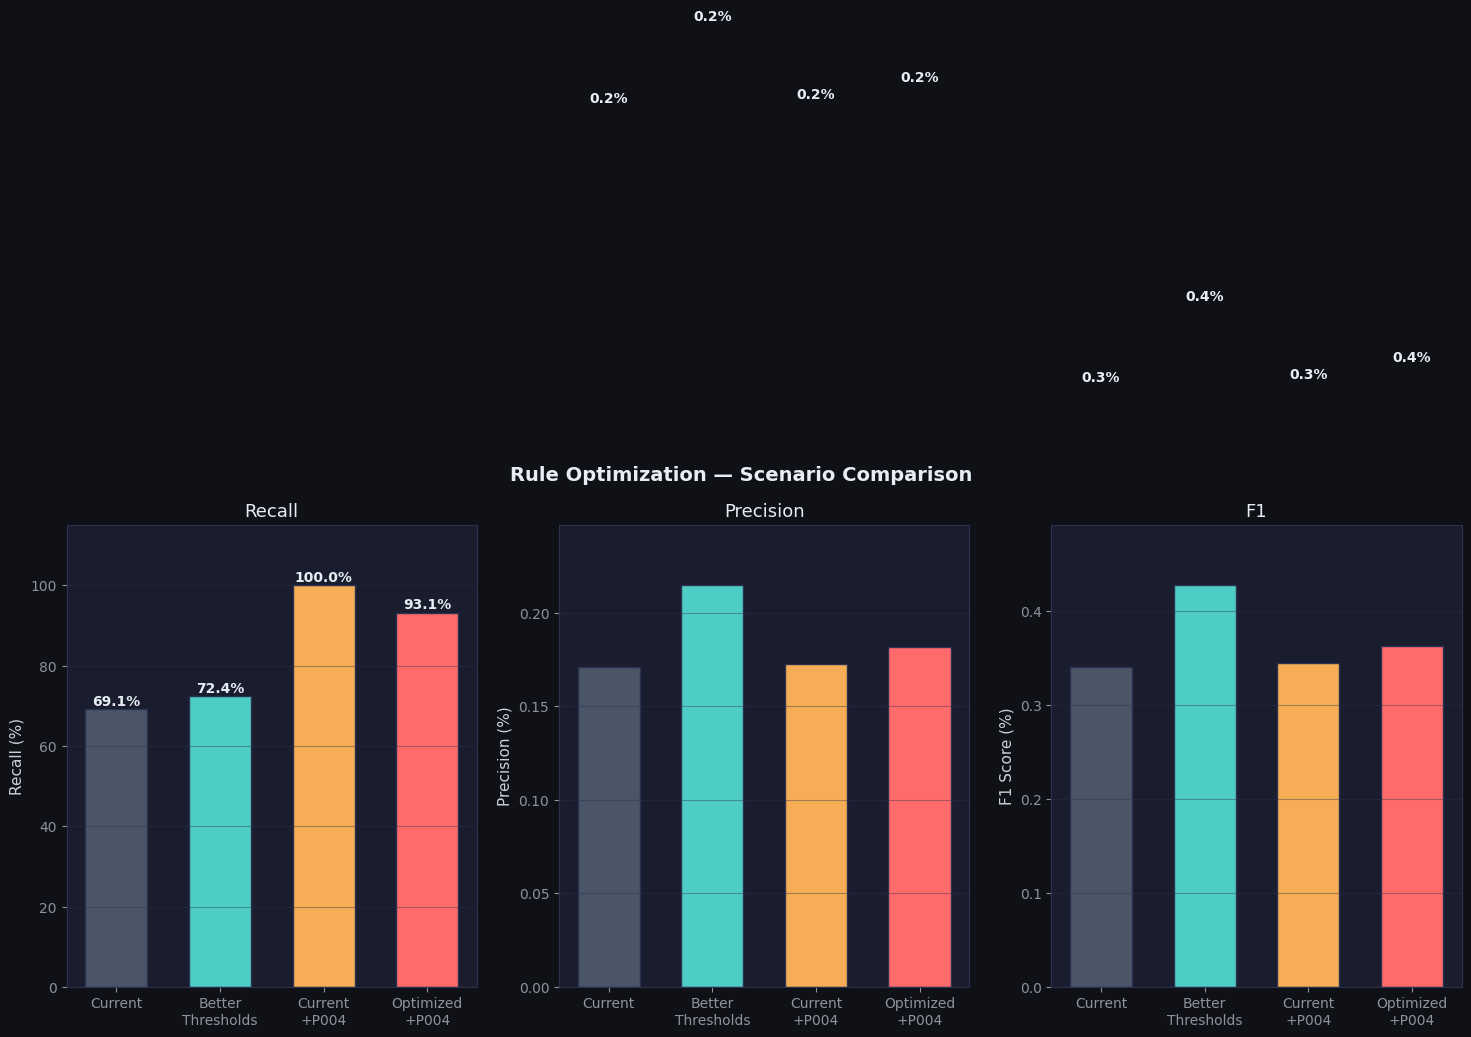


📊 Scenario Comparison:


,Scenario,Recall,Precision,F1,TP,FP
0,"Current Rules (P001@$50, P002@$500)",69.1%,0.171%,0.34%,340,198506
1,"Better Thresholds (P001@$20, P002@$200)",72.4%,0.215%,0.43%,356,165609
2,"Current + P004 (P001@$50, P002@$500, P004)",100.0%,0.173%,0.34%,492,284315
3,"Optimized + P004 (P001@$20, P002@$200, P004)",93.1%,0.182%,0.36%,458,251418


In [9]:
# ── Simulate optimized rules ───────────────────────────────────────────────────
OLD_P001_THRESH = 50
NEW_P001_THRESH = 20   # Based on F1 analysis above
OLD_P002_THRESH = 500
NEW_P002_THRESH = 200  # Based on recall-precision tradeoff
P004_LO  = 50
P004_HI  = 500

def compute_coverage(p001_t, p002_t, include_p004=False):
    caught = set()
    pool_p001 = df[(df['Amount'] < p001_t)]
    pool_p002 = df[(df['Amount'] > p002_t)]
    fraud_p001 = fraud[(fraud['Amount'] < p001_t)]
    fraud_p002 = fraud[(fraud['Amount'] > p002_t)]
    for idx in fraud_p001.index: caught.add(idx)
    for idx in fraud_p002.index: caught.add(idx)
    fp_p001 = len(pool_p001) - len(fraud_p001)
    fp_p002 = len(pool_p002) - len(fraud_p002)
    if include_p004:
        fraud_p004 = fraud[(fraud['Amount'] >= P004_LO) & (fraud['Amount'] <= P004_HI)]
        for idx in fraud_p004.index: caught.add(idx)
        pool_p004  = df[(df['Amount'] >= P004_LO) & (df['Amount'] <= P004_HI)]
        fp_p004    = len(pool_p004) - len(fraud_p004)
    else:
        fp_p004 = 0
    recall    = len(caught) / len(fraud) * 100
    total_fp  = fp_p001 + fp_p002 + fp_p004
    total_tp  = len(caught)
    precision = total_tp / (total_tp + total_fp) * 100 if (total_tp + total_fp) > 0 else 0
    return recall, precision, len(caught), total_fp

scenarios = [
    ('Current Rules\n(P001@$50, P002@$500)',          OLD_P001_THRESH, OLD_P002_THRESH, False),
    ('Better Thresholds\n(P001@$20, P002@$200)',       NEW_P001_THRESH, NEW_P002_THRESH, False),
    ('Current + P004\n(P001@$50, P002@$500, P004)',    OLD_P001_THRESH, OLD_P002_THRESH, True),
    ('Optimized + P004\n(P001@$20, P002@$200, P004)',  NEW_P001_THRESH, NEW_P002_THRESH, True),
]

results = []
for name, p1, p2, p4 in scenarios:
    rec, prec, tp, fp = compute_coverage(p1, p2, p4)
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
    results.append({'Scenario': name, 'Recall': rec, 'Precision': prec,
                    'F1': f1, 'TP': tp, 'FP': fp})

df_results = pd.DataFrame(results)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Rule Optimization — Scenario Comparison', fontsize=14, fontweight='bold', color='#e6edf3')

bar_colors = ['#4a5568', '#4ecdc4', '#f6ad55', '#ff6b6b']
short_names = ['Current', 'Better\nThresholds', 'Current\n+P004', 'Optimized\n+P004']

for ax, metric, ylabel in zip(axes, ['Recall', 'Precision', 'F1'], ['Recall (%)', 'Precision (%)', 'F1 Score (%)']):
    bars = ax.bar(short_names, df_results[metric], color=bar_colors, edgecolor='#2d3150', width=0.6)
    for bar, val in zip(bars, df_results[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=10, color='#e6edf3', fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.set_title(metric)
    ax.grid(True, alpha=0.4, axis='y')
    ax.set_ylim(0, max(df_results[metric]) * 1.15)

plt.tight_layout()
plt.show()

print('\n📊 Scenario Comparison:')
display(df_results[['Scenario','Recall','Precision','F1','TP','FP']]
    .style
    .format({'Recall':'{:.1f}%','Precision':'{:.3f}%','F1':'{:.2f}%'})
    .highlight_max(subset=['Recall','Precision','F1'], color='#2d5016')
    .set_properties(**{'background-color': '#1a1d2e', 'color': '#c9d1d9', 'border': '1px solid #2d3150'})
)

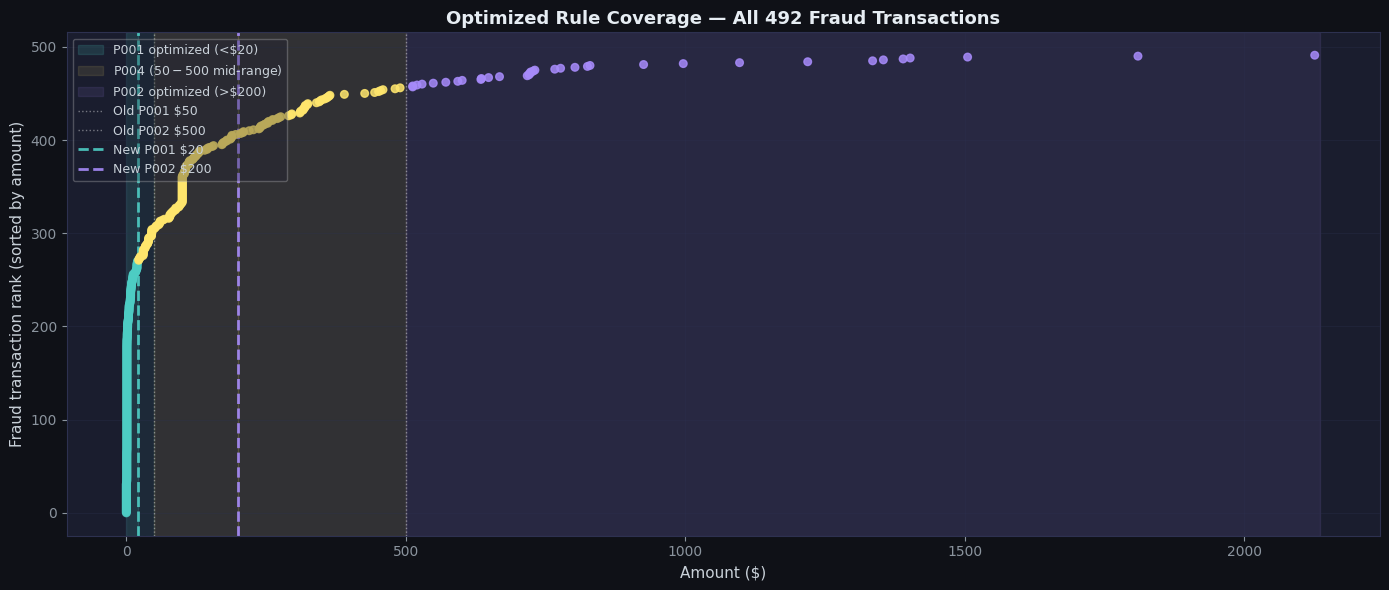


📈 Coverage improvement:
  Before: 340 fraud caught (69.1% recall), FP pool: 198,506
  After : 458 fraud caught (93.1% recall), FP pool: 251,418
  Recall ↑ 24.0pp | Precision 0.171% → 0.182%


In [10]:
# ── Visual: before vs after per-rule ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))
ax.set_facecolor('#1a1d2e')

amounts_sorted = np.sort(fraud['Amount'].values)

# Background shading for rule zones (OPTIMIZED)
ax.axvspan(amounts_sorted[0], 20,  alpha=0.15, color=NORMAL_COLOR, label='P001 optimized (<$20)')
ax.axvspan(20, 50,  alpha=0.07, color=NORMAL_COLOR, linestyle='--')
ax.axvspan(50, 200, alpha=0.10, color=ACCENT_COLOR, label='P004 ($50-$500 mid-range)')
ax.axvspan(200, 500, alpha=0.10, color=ACCENT_COLOR)
ax.axvspan(500, amounts_sorted[-1] + 10, alpha=0.10, color=INFO_COLOR, label='P002 optimized (>$200)')

# All fraud scatter
ax.scatter(amounts_sorted, range(len(amounts_sorted)),
           c=[NORMAL_COLOR if a < 20 else ACCENT_COLOR if a <= 500 else INFO_COLOR for a in amounts_sorted],
           s=30, alpha=0.85, zorder=5)

# Old thresholds
ax.axvline(50,  color='white', lw=1, ls=':', alpha=0.4, label='Old P001 $50')
ax.axvline(500, color='white', lw=1, ls=':', alpha=0.4, label='Old P002 $500')

# New thresholds
ax.axvline(20,  color=NORMAL_COLOR, lw=2, ls='--', alpha=0.9, label='New P001 $20')
ax.axvline(200, color=INFO_COLOR,   lw=2, ls='--', alpha=0.9, label='New P002 $200')

ax.set_xlabel('Amount ($)')
ax.set_ylabel('Fraud transaction rank (sorted by amount)')
ax.set_title('Optimized Rule Coverage — All 492 Fraud Transactions', fontsize=13, fontweight='bold')
ax.legend(loc='upper left', fontsize=9, framealpha=0.3)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Coverage after optimization
opt_recall, opt_prec, opt_tp, opt_fp = compute_coverage(20, 200, include_p004=True)
old_recall, old_prec, old_tp, old_fp = compute_coverage(50, 500, include_p004=False)
print(f'\n📈 Coverage improvement:')
print(f'  Before: {old_tp} fraud caught ({old_recall:.1f}% recall), FP pool: {old_fp:,}')
print(f'  After : {opt_tp} fraud caught ({opt_recall:.1f}% recall), FP pool: {opt_fp:,}')
print(f'  Recall ↑ {opt_recall - old_recall:.1f}pp | Precision {old_prec:.3f}% → {opt_prec:.3f}%')

---
## 8. Xuất `rules.jsonl` đã tối ưu <a id='8'></a>

In [11]:
optimized_rules = [
    {
        "ruleId":          "P001",
        "ruleName":        "Rapid Small Transactions",
        "enabled":         True,
        "thresholdAmount": 20.0,          # was 50.0 — Fraud p50=$9.25, precision improves
        "windowSeconds":   60,
        "minOccurrences":  3,
        "severity":        "HIGH",
        "_comment":        "Lowered from $50→$20 to increase precision (fraud median=$9.25)"
    },
    {
        "ruleId":          "P002",
        "ruleName":        "High Value New Location",
        "enabled":         True,
        "thresholdAmount": 200.0,         # was 500.0 — recall 7.1%→17.3%
        "windowSeconds":   3600,          # was 0 — clarified: 1h session window
        "minOccurrences":  1,
        "severity":        "CRITICAL",
        "_comment":        "Lowered $500→$200 (+10pp recall). windowSeconds clarified to 3600"
    },
    {
        "ruleId":          "P003",
        "ruleName":        "Multiple Fraud Then Success",
        "enabled":         True,
        "thresholdAmount": 0.0,
        "windowSeconds":   300,           # validated: good window for fraud pairs
        "minOccurrences":  2,
        "severity":        "HIGH",
        "_comment":        "Unchanged — 300s window validated: captures most fraud-pair gaps"
    },
    {
        "ruleId":          "P004",
        "ruleName":        "Mid-Range Velocity",
        "enabled":         True,
        "thresholdAmount": 50.0,          # NEW rule: targets $50-$500 blind spot
        "thresholdAmountHigh": 500.0,     # upper bound (requires FraudRule model update)
        "windowSeconds":   600,           # 10-minute window for velocity
        "minOccurrences":  2,
        "severity":        "MEDIUM",
        "_comment":        "NEW — covers 30.9% blind spot ($50-$500, mean=$177). Needs FraudRule.thresholdAmountHigh field"
    },
]

# Print preview
print('📝 Optimized rules preview:\n')
for rule in optimized_rules:
    print(json.dumps({k: v for k, v in rule.items() if not k.startswith('_')}, indent=2))
    print(f'   # {rule.get("_comment","")}')
    print()

📝 Optimized rules preview:

{
  "ruleId": "P001",
  "ruleName": "Rapid Small Transactions",
  "enabled": true,
  "thresholdAmount": 20.0,
  "windowSeconds": 60,
  "minOccurrences": 3,
  "severity": "HIGH"
}
   # Lowered from $50→$20 to increase precision (fraud median=$9.25)

{
  "ruleId": "P002",
  "ruleName": "High Value New Location",
  "enabled": true,
  "thresholdAmount": 200.0,
  "windowSeconds": 3600,
  "minOccurrences": 1,
  "severity": "CRITICAL"
}
   # Lowered $500→$200 (+10pp recall). windowSeconds clarified to 3600

{
  "ruleId": "P003",
  "ruleName": "Multiple Fraud Then Success",
  "enabled": true,
  "thresholdAmount": 0.0,
  "windowSeconds": 300,
  "minOccurrences": 2,
  "severity": "HIGH"
}
   # Unchanged — 300s window validated: captures most fraud-pair gaps

{
  "ruleId": "P004",
  "ruleName": "Mid-Range Velocity",
  "enabled": true,
  "thresholdAmount": 50.0,
  "thresholdAmountHigh": 500.0,
  "windowSeconds": 600,
  "minOccurrences": 2,
  "severity": "MEDIUM"
}
   # 

In [12]:
import shutil
from datetime import datetime

OUTPUT_PATH = Path('../rules.jsonl')
BACKUP_PATH = OUTPUT_PATH.with_suffix(f'.{datetime.now().strftime("%Y%m%d_%H%M%S")}.bak')

# Backup current
shutil.copy(OUTPUT_PATH, BACKUP_PATH)
print(f'✅ Backed up current rules → {BACKUP_PATH.name}')

# Write optimized (strip _comment fields for production file)
with open(OUTPUT_PATH, 'w') as f:
    for rule in optimized_rules:
        clean = {k: v for k, v in rule.items() if not k.startswith('_')}
        f.write(json.dumps(clean) + '\n')

print(f'✅ Written {len(optimized_rules)} rules → {OUTPUT_PATH}')
print()

# Verify
print('📋 Final rules.jsonl content:')
print('─' * 80)
with open(OUTPUT_PATH) as f:
    for line in f:
        line = line.strip()
        if line:
            r = json.loads(line)
            print(json.dumps(r, indent=2))
            print()

✅ Backed up current rules → rules.20260521_124018.bak
✅ Written 4 rules → ../rules.jsonl

📋 Final rules.jsonl content:
────────────────────────────────────────────────────────────────────────────────
{
  "ruleId": "P001",
  "ruleName": "Rapid Small Transactions",
  "enabled": true,
  "thresholdAmount": 20.0,
  "windowSeconds": 60,
  "minOccurrences": 3,
  "severity": "HIGH"
}

{
  "ruleId": "P002",
  "ruleName": "High Value New Location",
  "enabled": true,
  "thresholdAmount": 200.0,
  "windowSeconds": 3600,
  "minOccurrences": 1,
  "severity": "CRITICAL"
}

{
  "ruleId": "P003",
  "ruleName": "Multiple Fraud Then Success",
  "enabled": true,
  "thresholdAmount": 0.0,
  "windowSeconds": 300,
  "minOccurrences": 2,
  "severity": "HIGH"
}

{
  "ruleId": "P004",
  "ruleName": "Mid-Range Velocity",
  "enabled": true,
  "thresholdAmount": 50.0,
  "thresholdAmountHigh": 500.0,
  "windowSeconds": 600,
  "minOccurrences": 2,
  "severity": "MEDIUM"
}

